In [1]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, f1_score
import time

import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

from rital_nlp_project.common.utils import load_clean_data
from rital_nlp_project.common.notebook_utils import init_notebook
import rital_nlp_project.common.eda as eda

%load_ext autoreload
%autoreload 2

In [2]:
texts_movies, classes_movies = load_clean_data("../Dataset/movies_clean.parquet")

Vocab length: 21959


<Axes: ylabel='Count'>

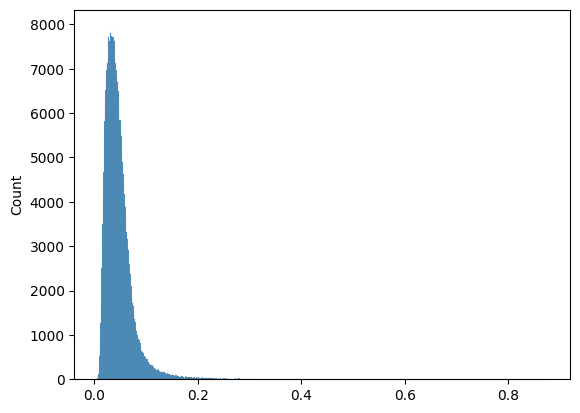

In [3]:
vectorizer = TfidfVectorizer(min_df=5, max_df=0.50, ngram_range=(1, 2))
vectors = vectorizer.fit_transform(texts_movies)
vocab = vectorizer.get_feature_names_out()
print("Vocab length:", len(vocab))
sns.histplot(vectors.data)

### Models

##### Tested models
- SVM 
- Multinomila Naive Bayes
- Logistic regression

##### Granularity
- Characters
- Tokens of size 3 characters
- Words

In [4]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(texts_movies, classes_movies, random_state=42)

#### Combination matrix

In [5]:
max_features = 5000
min_df = 5
max_df = 0.5
vectorizer_list = [
    CountVectorizer(analyzer="char", ngram_range=(1, 1), max_features=max_features),
    CountVectorizer(analyzer="char_wb", ngram_range=(4, 4), max_features=max_features, min_df=min_df, max_df=max_df),
    CountVectorizer(analyzer="word", ngram_range=(1, 1), max_features=max_features, min_df=min_df, max_df=max_df),
    CountVectorizer(analyzer="word", ngram_range=(1, 3), max_features=max_features, min_df=min_df, max_df=max_df),
    TfidfVectorizer(analyzer="char_wb", ngram_range=(4, 4), max_features=max_features, min_df=min_df, max_df=max_df),

    TfidfVectorizer(analyzer="word", ngram_range=(1, 1), max_features=max_features, min_df=min_df, max_df=max_df),
    TfidfVectorizer(analyzer="word", ngram_range=(1, 3), max_features=max_features, min_df=min_df, max_df=max_df),
]

classifier_list = [
    LogisticRegression(max_iter=100),
    MultinomialNB(), 
    LinearSVC(),
    SVC(kernel="rbf")
]

In [7]:
results = []
for vect in vectorizer_list:
    for clf in classifier_list:
        pipe = Pipeline([("vectorizer", vect), ("classifier", clf)])
        print(pipe)
        # Train-test eval
        t0 = time.time()
        pipe.fit(X_train, y_train)
        train_time = time.time() - t0

        t0 = time.time()
        preds = pipe.predict(X_test)
        inference_time = time.time() - t0
        
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average="weighted")

        # Cross-val eval
        mean_acc = np.mean(cross_val_score(pipe, X_train, y_train, cv=5, scoring="accuracy"))

        results.append({
            "vectorizer": vect,
            "classifier": clf,
            "accuracy": acc,
            "f1": f1,
            "train_time": train_time,
            "inference_time": inference_time,
            "cross_val_accuracy":mean_acc,
        })
results = pd.DataFrame(results)
results.to_csv("out/baseline_eval_matrix.csv", index=False)

Pipeline(steps=[('vectorizer',
                 CountVectorizer(analyzer='char', max_features=5000)),
                ('classifier', LogisticRegression())])


/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the d

Pipeline(steps=[('vectorizer',
                 CountVectorizer(analyzer='char', max_features=5000)),
                ('classifier', MultinomialNB())])
Pipeline(steps=[('vectorizer',
                 CountVectorizer(analyzer='char', max_features=5000)),
                ('classifier', LinearSVC())])
Pipeline(steps=[('vectorizer',
                 CountVectorizer(analyzer='char', max_features=5000)),
                ('classifier', SVC())])
Pipeline(steps=[('vectorizer',
                 CountVectorizer(analyzer='char_wb', max_df=0.5,
                                 max_features=5000, min_df=5,
                                 ngram_range=(4, 4))),
                ('classifier', LogisticRegression())])
Pipeline(steps=[('vectorizer',
                 CountVectorizer(analyzer='char_wb', max_df=0.5,
                                 max_features=5000, min_df=5,
                                 ngram_range=(4, 4))),
                ('classifier', MultinomialNB())])
Pipeline(steps=[('vectorize

/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('vectorizer',
                 CountVectorizer(analyzer='char_wb', max_df=0.5,
                                 max_features=5000, min_df=5,
                                 ngram_range=(4, 4))),
                ('classifier', SVC())])
Pipeline(steps=[('vectorizer',
                 CountVectorizer(max_df=0.5, max_features=5000, min_df=5)),
                ('classifier', LogisticRegression())])
Pipeline(steps=[('vectorizer',
                 CountVectorizer(max_df=0.5, max_features=5000, min_df=5)),
                ('classifier', MultinomialNB())])
Pipeline(steps=[('vectorizer',
                 CountVectorizer(max_df=0.5, max_features=5000, min_df=5)),
                ('classifier', LinearSVC())])


/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('vectorizer',
                 CountVectorizer(max_df=0.5, max_features=5000, min_df=5)),
                ('classifier', SVC())])
Pipeline(steps=[('vectorizer',
                 CountVectorizer(max_df=0.5, max_features=5000, min_df=5,
                                 ngram_range=(1, 3))),
                ('classifier', LogisticRegression())])
Pipeline(steps=[('vectorizer',
                 CountVectorizer(max_df=0.5, max_features=5000, min_df=5,
                                 ngram_range=(1, 3))),
                ('classifier', MultinomialNB())])
Pipeline(steps=[('vectorizer',
                 CountVectorizer(max_df=0.5, max_features=5000, min_df=5,
                                 ngram_range=(1, 3))),
                ('classifier', LinearSVC())])


/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('vectorizer',
                 CountVectorizer(max_df=0.5, max_features=5000, min_df=5,
                                 ngram_range=(1, 3))),
                ('classifier', SVC())])
Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(analyzer='char_wb', max_df=0.5,
                                 max_features=5000, min_df=5,
                                 ngram_range=(4, 4))),
                ('classifier', LogisticRegression())])
Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(analyzer='char_wb', max_df=0.5,
                                 max_features=5000, min_df=5,
                                 ngram_range=(4, 4))),
                ('classifier', MultinomialNB())])
Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(analyzer='char_wb', max_df=0.5,
                                 max_features=5000, min_df=5,
                                 ngram_range=(4, 4))),
                ('classifier', LinearSVC())])
Pipeline(s

Text(0.5, 1.0, 'Accuracy')

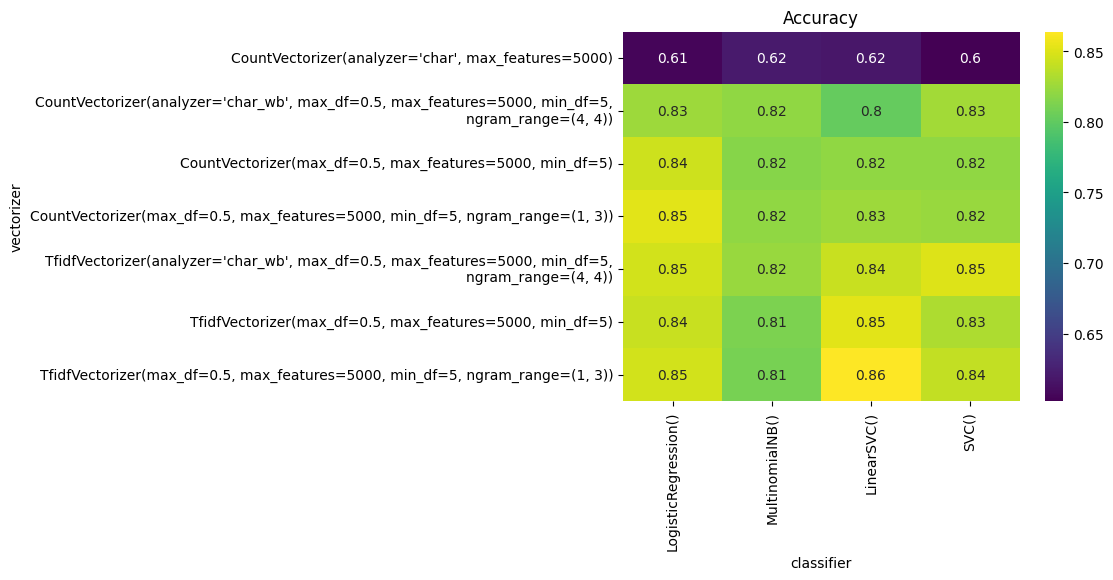

In [24]:
sns.heatmap(results.pivot(columns="classifier", index="vectorizer", values="accuracy"), annot=True, cmap="viridis")
plt.title("Accuracy")

Text(0.5, 1.0, 'F1-score')

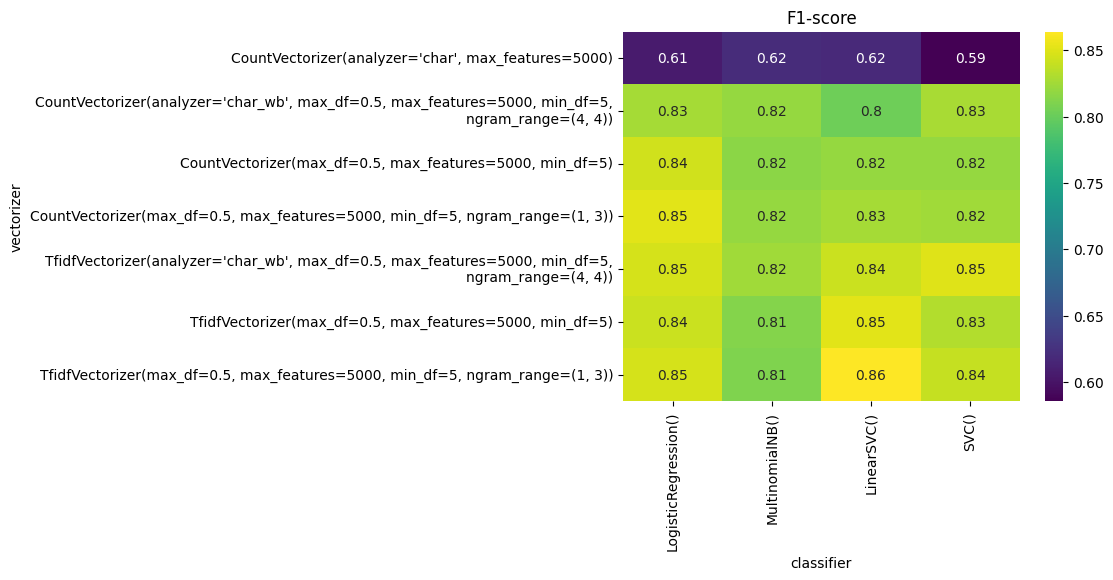

In [21]:
sns.heatmap(results.pivot(columns="classifier", index="vectorizer", values="f1"), annot=True, cmap="viridis")
plt.title("F1-score")

Text(0.5, 1.0, 'Train time')

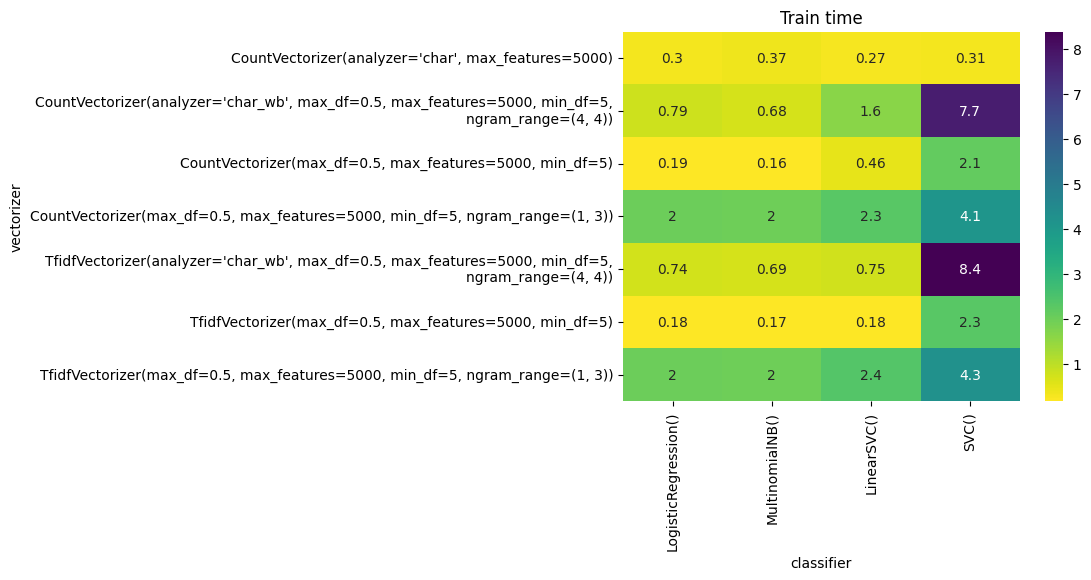

In [22]:
sns.heatmap(results.pivot(columns="classifier", index="vectorizer", values="train_time"), annot=True, cmap="viridis_r")
plt.title("Train time")

#### Separate pipeline eval

In [38]:
def eval_pipeline(pipeline, clf_report:bool=False):
    # Pipeline desc
    print("Pipeline steps:")
    for name, step in pipeline.named_steps.items():
        print(f"  {name}: {step}")

    # Cross validation
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
    print(f"Scores : {scores}, mean score : {np.mean(scores)}")

    # Training time
    t0 = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - t0
    print(f"Training time: {train_time:.3f} seconds")

    # Inference time
    t0 = time.time()
    predictions = pipeline.predict(X_test)
    infer_time = time.time() - t0
    print(f"Inference time: {infer_time:.3f} seconds")

    print("Vocabulary size:", len(pipeline.named_steps["vectorizer"].vocabulary_))
    print("Train/test accuracy score:", accuracy_score(y_test, predictions))
    if clf_report:
        print(classification_report(y_test, predictions))
    print()

In [40]:
pipeline = Pipeline([
    ("vectorizer", CountVectorizer(analyzer="char", ngram_range=(1, 1))),
    ("classifier", MultinomialNB()) 
])
eval_pipeline(pipeline)

pipeline = Pipeline([
    ("vectorizer", CountVectorizer(min_df=5, max_df=0.5, analyzer="char_wb", ngram_range=(3, 3))),
    ("classifier", MultinomialNB()) 
])
eval_pipeline(pipeline)

pipeline = Pipeline([
    ("vectorizer", CountVectorizer(min_df=5, max_df=0.5, analyzer="word", ngram_range=(1, 1))),
    ("classifier", MultinomialNB()) 
])
eval_pipeline(pipeline)

pipeline = Pipeline([
    ("vectorizer", CountVectorizer(min_df=5, max_df=0.5, analyzer="word", ngram_range=(1, 3), max_features=10000)),
    ("classifier", MultinomialNB()) 
])
eval_pipeline(pipeline)

Pipeline steps:
  vectorizer: CountVectorizer(analyzer='char')
  classifier: MultinomialNB()
Scores : [0.59       0.56333333 0.69333333 0.58666667 0.66      ], mean score : 0.6186666666666667
Training time: 0.245 seconds
Inference time: 0.080 seconds
Vocabulary size: 33
Train/test accuracy score: 0.62

Pipeline steps:
  vectorizer: CountVectorizer(analyzer='char_wb', max_df=0.5, min_df=5, ngram_range=(3, 3))
  classifier: MultinomialNB()
Scores : [0.78333333 0.77666667 0.76666667 0.72666667 0.77666667], mean score : 0.766
Training time: 0.711 seconds
Inference time: 0.223 seconds
Vocabulary size: 4512
Train/test accuracy score: 0.76

Pipeline steps:
  vectorizer: CountVectorizer(max_df=0.5, min_df=5)
  classifier: MultinomialNB()
Scores : [0.84333333 0.83666667 0.83333333 0.71666667 0.83      ], mean score : 0.812
Training time: 0.159 seconds
Inference time: 0.044 seconds
Vocabulary size: 9020
Train/test accuracy score: 0.828

Pipeline steps:
  vectorizer: CountVectorizer(max_df=0.5, m